In [1]:
import torch

from perspective import Retina, Monitor, Perspective

from nnfabrik.builder import get_data, get_trainer

from sensorium2020_adapted import stacked_core_full_gauss_readout

import matplotlib.pyplot as plt

random_seed = 42

device = "cuda:7"
torch.cuda.set_device(device)

In [2]:
# loading the SENSORIUM+ dataset
filenames = ['/srv/user/polina/sensorium/sensorium/notebooks/data/static27204-5-13-GrayImageNet-94c6ff995dac583098847cfecd43e7b6.zip', ]

dataset_fn = 'sensorium.datasets.static_loaders'
dataset_config = {'paths': filenames,
                 'normalize': True,
                 'include_behavior': False,
                 'include_eye_position': True,
                 'batch_size': 128,
                 'scale':0.25,
                 }

dataloaders = get_data(dataset_fn, dataset_config)

In [3]:
grid_mean_predictor = {
    'type': 'cortex',
    'input_dimensions': 2,
    'hidden_layers': 1,
    'hidden_features': 30,
    'final_tanh': True
}

model_config = {'pad_input': False,
  'stack': -1,
  'layers': 4,
  'input_kern': 9,
  'gamma_input': 6.3831,
  'gamma_readout': 0.0076,
  'hidden_kern': 7,
  'hidden_channels': 64,
  'depth_separable': True,
  'grid_mean_predictor': {'type': 'cortex',
   'input_dimensions': 2,
   'hidden_layers': 1,
   'hidden_features': 30,
   'final_tanh': True},
  'init_sigma': 0.1,
  'init_mu_range': 0.3,
  'gauss_type': 'full',
  'shifter': False,
}

perspective = Perspective(Retina(device=device), Monitor(device=device)).to(device)
model_config['perspective'] = perspective

In [4]:
model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


In [5]:
trainer_fn = "sensorium.training.standard_trainer"

trainer_config = {'max_iter': 200,
                 'verbose': False,
                 'lr_decay_steps': 4,
                 'avg_loss': False,
                 'lr_init': 0.009,
                 'track_training': False,
                 }

trainer_config['device'] = 'cuda:7'

trainer = get_trainer(trainer_fn=trainer_fn, 
                     trainer_config=trainer_config)

In [6]:
validation_score, trainer_output, state_dict = trainer(model, dataloaders, seed=random_seed)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/gaussian.py:582: UserWarning: the specified feature map dimension is not the readout's expected input dimension
  warnings.warn("the specified feature map dimension is not the readout's expected input dimension")
Epoch 112: 100%|██████████| 35/35 [00:20<00:00,  1.71it/s]


In [7]:
validation_score

np.float32(0.33684915)

In [8]:
list(perspective.parameters())

[Parameter containing:
 tensor([[-0.1927,  0.3894],
         [-0.0029,  0.0039],
         [-0.1485,  0.2146],
         [-0.0103, -0.0161],
         [-0.4466, -0.4829],
         [ 0.5428, -0.2258],
         [ 0.2031,  0.6853],
         [-0.7007,  0.3555],
         [-0.4112,  0.4775],
         [-0.3396, -0.0624],
         [-0.4160,  0.0367],
         [-0.1591, -0.0653],
         [ 0.6826,  0.1226],
         [ 0.0013, -0.0048],
         [-0.2177, -0.1835],
         [ 0.2220, -0.6103]], device='cuda:7', requires_grad=True),
 Parameter containing:
 tensor([ 1.8346e-01,  6.7894e-04,  2.2326e-01,  2.8772e-03, -1.2633e-01,
         -1.5512e-01, -6.4149e-01, -5.3144e-01, -6.4898e-01, -4.6226e-01,
         -6.7017e-04,  1.5176e-01, -3.5540e-01, -1.3126e-03,  2.5140e-01,
         -6.7805e-01], device='cuda:7', requires_grad=True),
 Parameter containing:
 tensor([[ 7.4492e-02,  4.2041e-02, -6.9080e-02, -1.1538e-01, -3.8257e-01,
          -1.4043e-01, -3.0768e-01,  3.7651e-01,  4.5915e-02, -1.6375e

tensor(1.5840)
tensor(0.5322)
tensor(0.5110)
tensor(0.3227)
tensor(-0.7182)
tensor(0.1660)
tensor(-3.6712)
tensor(-0.6652)
tensor(-0.6982)
tensor(0.0324)


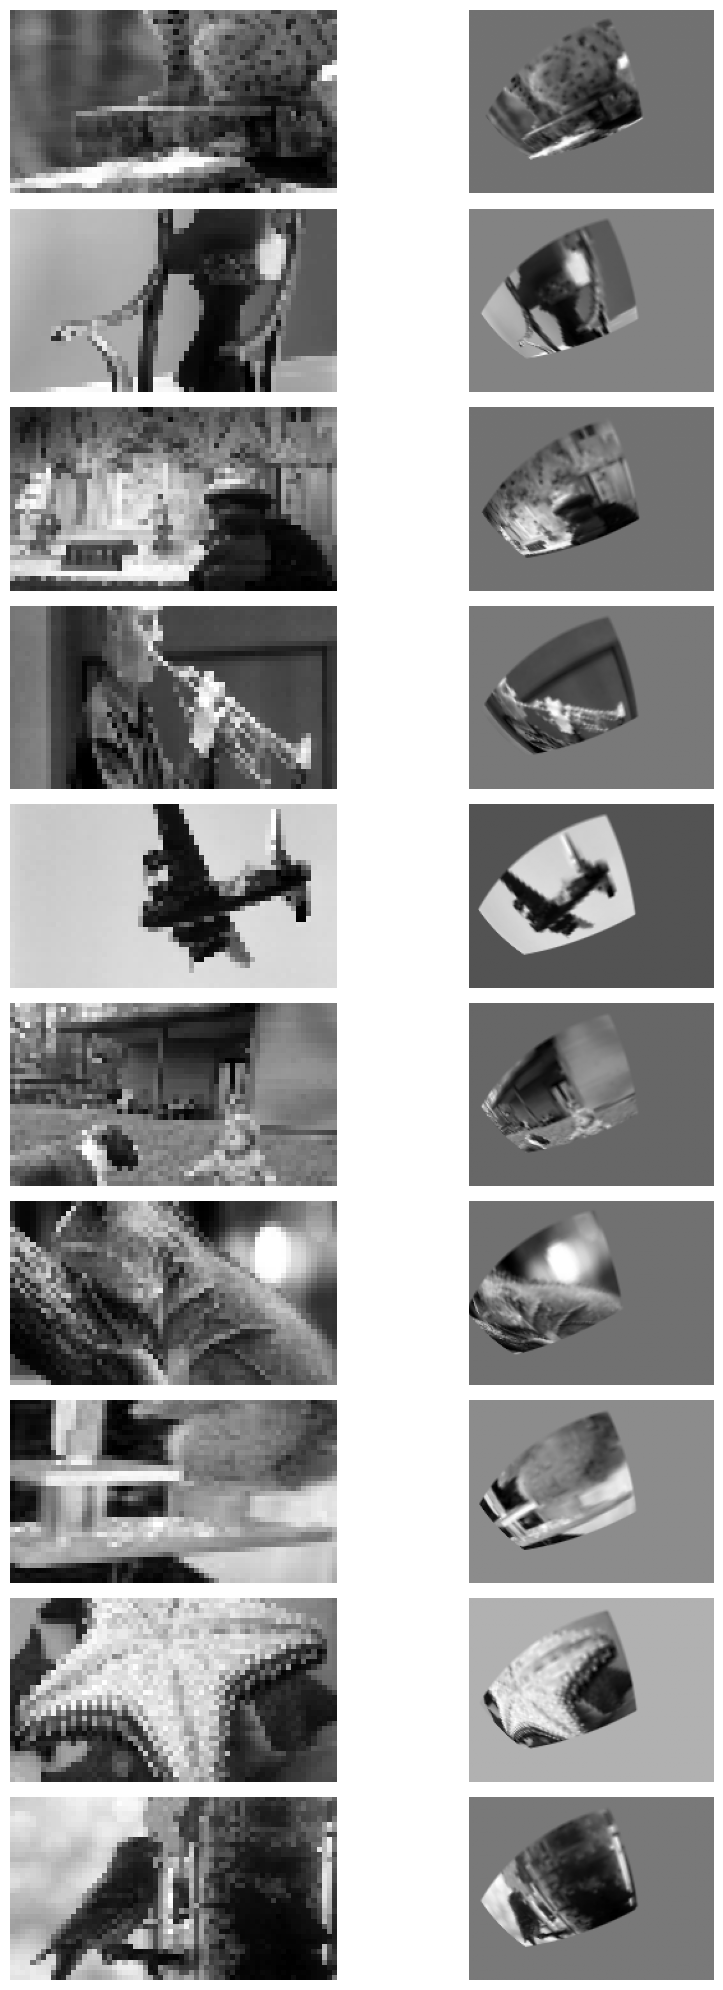

In [9]:
data_key = "27204-5-13"
batch = next(iter(dataloaders["train"][data_key]))

fig, ax = plt.subplots(10, 2, figsize=(10, 20))

for i in range(10):
    ax[i, 0].imshow(batch.images[i, 0].detach().cpu(), cmap='gray')
    ax[i, 0].axis('off')
    print(batch.pupil_center[i, 0].detach().cpu())
    ax[i, 1].imshow(perspective(batch.images, batch.pupil_center)[i, 0].detach().cpu(), cmap='gray')
    ax[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [12]:
perspective.retina.mlp

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): GELU(approximate='none')
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): GELU(approximate='none')
  (4): Linear(in_features=16, out_features=16, bias=True)
  (5): GELU(approximate='none')
  (6): Linear(in_features=16, out_features=3, bias=True)
)

In [10]:
perspective.retina.mlp(batch.pupil_center)

tensor([[0.1550, 0.2623, 0.1394],
        [0.1566, 0.3095, 0.1260],
        [0.1653, 0.3005, 0.1197],
        [0.1604, 0.3109, 0.1204],
        [0.1547, 0.3386, 0.1309],
        [0.1642, 0.3097, 0.1167],
        [0.1600, 0.4675, 0.1849],
        [0.1653, 0.3262, 0.1203],
        [0.1681, 0.3238, 0.1191],
        [0.1637, 0.3129, 0.1167],
        [0.1768, 0.3456, 0.1226],
        [0.1652, 0.3093, 0.1164],
        [0.1572, 0.3301, 0.1250],
        [0.1729, 0.3423, 0.1269],
        [0.1658, 0.3180, 0.1169],
        [0.1663, 0.3302, 0.1225],
        [0.1418, 0.3144, 0.1446],
        [0.1614, 0.2870, 0.1305],
        [0.1382, 0.2499, 0.1317],
        [0.1645, 0.3179, 0.1170],
        [0.1600, 0.3155, 0.1200],
        [0.1652, 0.3048, 0.1176],
        [0.1662, 0.2965, 0.1238],
        [0.1530, 0.4264, 0.1616],
        [0.1381, 0.3526, 0.1421],
        [0.1380, 0.3261, 0.1503],
        [0.1485, 0.3118, 0.1367],
        [0.1522, 0.3560, 0.1414],
        [0.1651, 0.3156, 0.1164],
        [0.157

seed 41 results:  
    Parameter containing:  
    tensor([-0.2717,  0.1146,  1.2536], device='cuda:7', requires_grad=True),  
    Parameter containing:  
    tensor([ 0.5564,  0.5958, -0.2947], device='cuda:7', requires_grad=True)  

seed 40 results:  
    Parameter containing:  
    tensor([-0.4187,  0.2635,  1.1136], device='cuda:7', requires_grad=True),  
    Parameter containing:  
    tensor([ 0.7092,  0.4121, -0.6947], device='cuda:7', requires_grad=True)  

seed 39 results:  
    Parameter containing:  
    tensor([-0.4425, -0.2122,  1.1337], device='cuda:7', requires_grad=True),  
    Parameter containing:  
    tensor([-0.2125,  0.5381,  0.8054], device='cuda:7', requires_grad=True)  